In [16]:
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
import pandas as pd
import seaborn as sns
import math
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [17]:
penguins = load_penguins()
data = pd.DataFrame(penguins)

features = data[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

data[['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']] = features_scaled

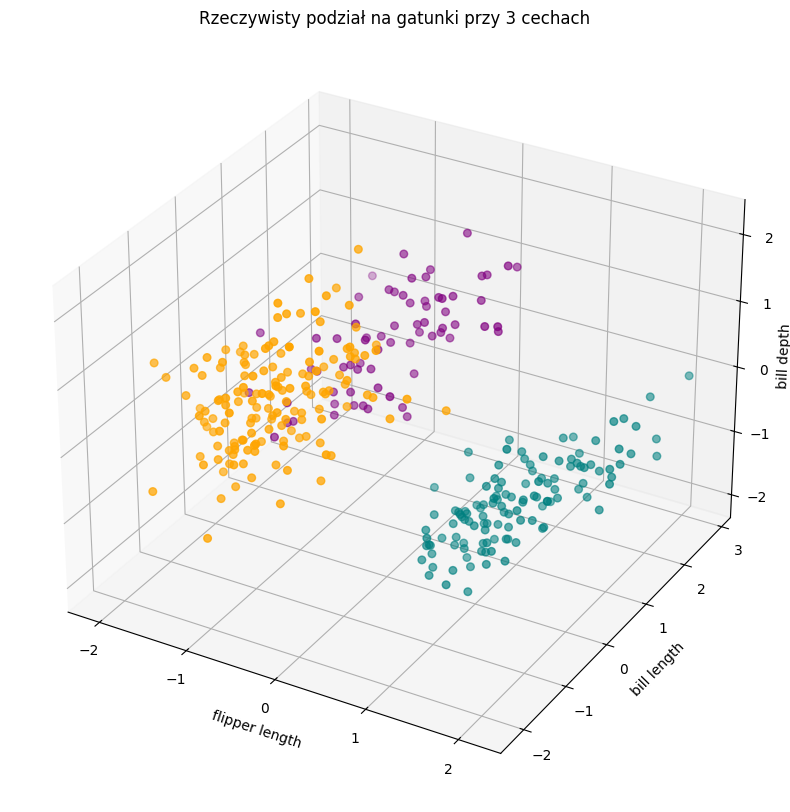

In [18]:
colors = {'Adelie': 'orange', 'Chinstrap': 'purple', 'Gentoo': 'teal'}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data['flipper_length_mm'], 
    data['bill_length_mm'], 
    data['bill_depth_mm'], 
    c=data['species'].map(colors), 
    s=30
)
ax.set_xlabel("flipper length")
ax.set_ylabel("bill length")
ax.set_zlabel("bill depth", labelpad=0)

plt.title("Rzeczywisty podział na gatunki przy 3 cechach")
plt.show()

Niebieska chmura punktów odpowiadająca gatunkowi Gentoo jest daleko od reszty, więc do klasyfikacji między nim a resztą gatunków można użyć SVM - Support Vector Machine.<br>
Pozostałe gatunki Adelie i Chinstrap, czyli żółte i fioletowe chumry punktów są lekko zmieszane, więc do klasyfikacji między nimi metod statystycznych Bayesowskich.

ETAP I - SVM

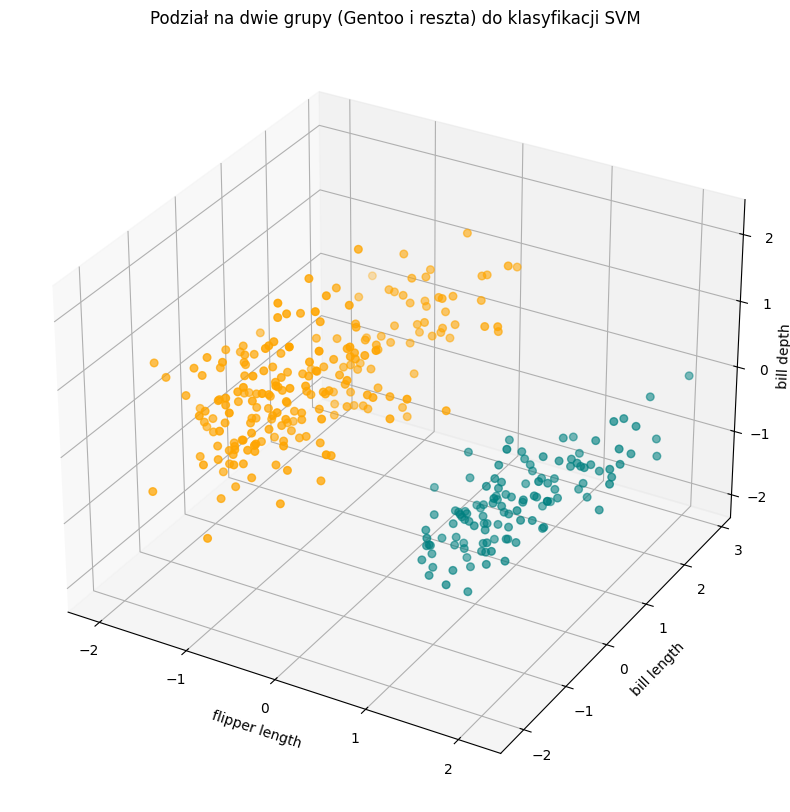

In [19]:
# SVM between Gentoo and rest
data_SVM = data[["flipper_length_mm", 'bill_length_mm', 'bill_depth_mm', 'species']]
data_SVM["SVM"] = 0
data_SVM.loc[data_SVM["species"] == "Gentoo", "SVM"] = 1



colors = {0: 'orange', 1: 'teal'}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data_SVM['flipper_length_mm'], 
    data_SVM['bill_length_mm'], 
    data_SVM['bill_depth_mm'], 
    c=data_SVM['SVM'].map(colors), 
    s=30
)
ax.set_xlabel("flipper length")
ax.set_ylabel("bill length")
ax.set_zlabel("bill depth", labelpad=0)

plt.title("Podział na dwie grupy (Gentoo i reszta) do klasyfikacji SVM")
plt.show()

Zamiast brać 3 najkrótsze dystanse z całej listy muszę wziąć te, które są najbliżej przeciwnika w różnych rejonach wykresu:<br>
Dlatego że wtedy nasza płaszczyzna oddzielająca chumry punktów będzie poprawna na całej szerokości danych a nie tylko w jednym miejscu gdzie dane są blisko
<br><br>
Para A: Para (Gentoo, Others) o najmniejszym dystansie, gdzie objekt Gentoo ma flipper_length wśród 10 NAJMNIEJSZYCH ze skupiska.<br>
Para B: Para (Gentoo, Others) o najmniejszym dystansie, gdzie objekt Gentoo ma flipper_length wśród 10 NAJWIĘKSZYCH ze skupiska.<br>
Para B: Para (Gentoo, Others) o najmniejszym dystansie, gdzie objekt Gentoo ma bill_length wśród 10 NAJMNIEJSZYCH ze skupiska.<br>

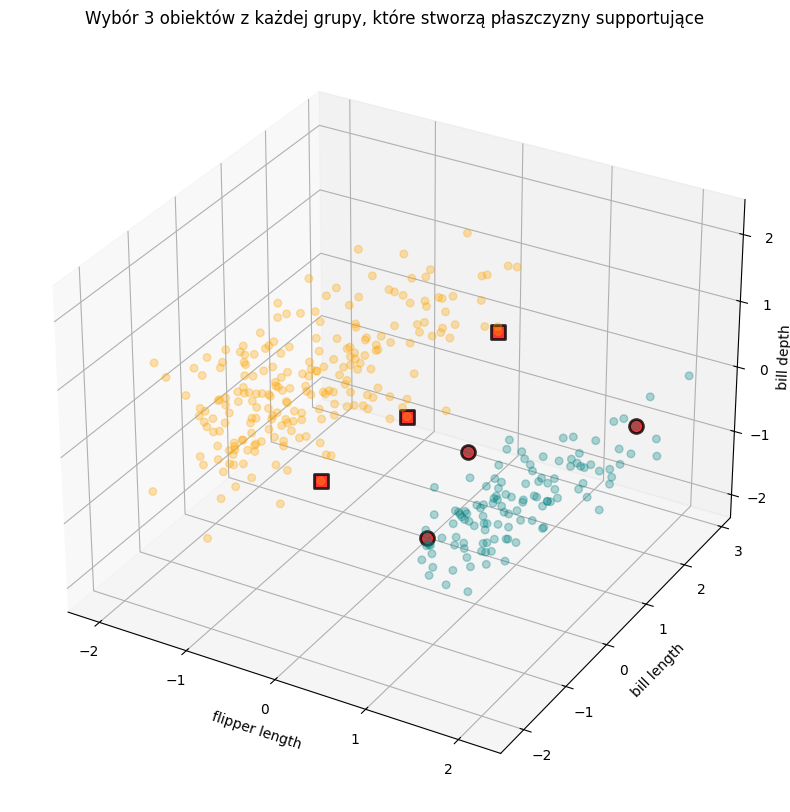

In [20]:
# klasyfikacja SVM

# znajduje tyle obiektów ile mam wymiarów (3) z każdej grupy
gentoo_obj = data_SVM.loc[data_SVM["SVM"] == 1, ["flipper_length_mm", 'bill_length_mm', 'bill_depth_mm']]
others_obj = data_SVM.loc[data_SVM["SVM"] == 0, ["flipper_length_mm", 'bill_length_mm', 'bill_depth_mm']]

def find_best_pair(subset_g, subset_o):
    best_dist = float('inf')
    res = None
    for idxg, g in subset_g.iterrows():
        for idxo, o in subset_o.iterrows():
            d = math.dist(g, o)
            if d < best_dist:
                best_dist = d
                res = [d, g, o]
    return res

# Wybieramy 3 pary z różnych rejonów
support_obj = []

# 1. Para o najmniejszym flipperze
support_obj.append(find_best_pair(gentoo_obj.nsmallest(10, 'flipper_length_mm'), others_obj))
# 2. Para o największym flipperze
support_obj.append(find_best_pair(gentoo_obj.nlargest(10, 'flipper_length_mm'), others_obj))
# 3. Para o najmniejszym bill_length
support_obj.append(find_best_pair(gentoo_obj.nsmallest(10, 'bill_length_mm'), others_obj))


colors = {0: 'orange', 1: 'teal'}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data_SVM['flipper_length_mm'], 
    data_SVM['bill_length_mm'], 
    data_SVM['bill_depth_mm'], 
    c=data_SVM['SVM'].map(colors), 
    s=30,
    alpha=0.3
)
for sup in support_obj:
    gentoo_obj = sup[1]
    ax.scatter(gentoo_obj["flipper_length_mm"], gentoo_obj["bill_length_mm"], gentoo_obj["bill_depth_mm"], c='red', s=100, marker='o', edgecolors='black',linewidths=2, alpha=0.8)
    other_obj = sup[2]
    ax.scatter(other_obj["flipper_length_mm"], other_obj["bill_length_mm"], other_obj["bill_depth_mm"], c='red', s=100, marker='s', edgecolors='black',linewidths=2, alpha=0.8)

ax.set_xlabel("flipper length")
ax.set_ylabel("bill length")
ax.set_zlabel("bill depth", labelpad=0)


plt.title("Wybór 3 obiektów z każdej grupy, które stworzą płaszczyzny supportujące")
plt.show()


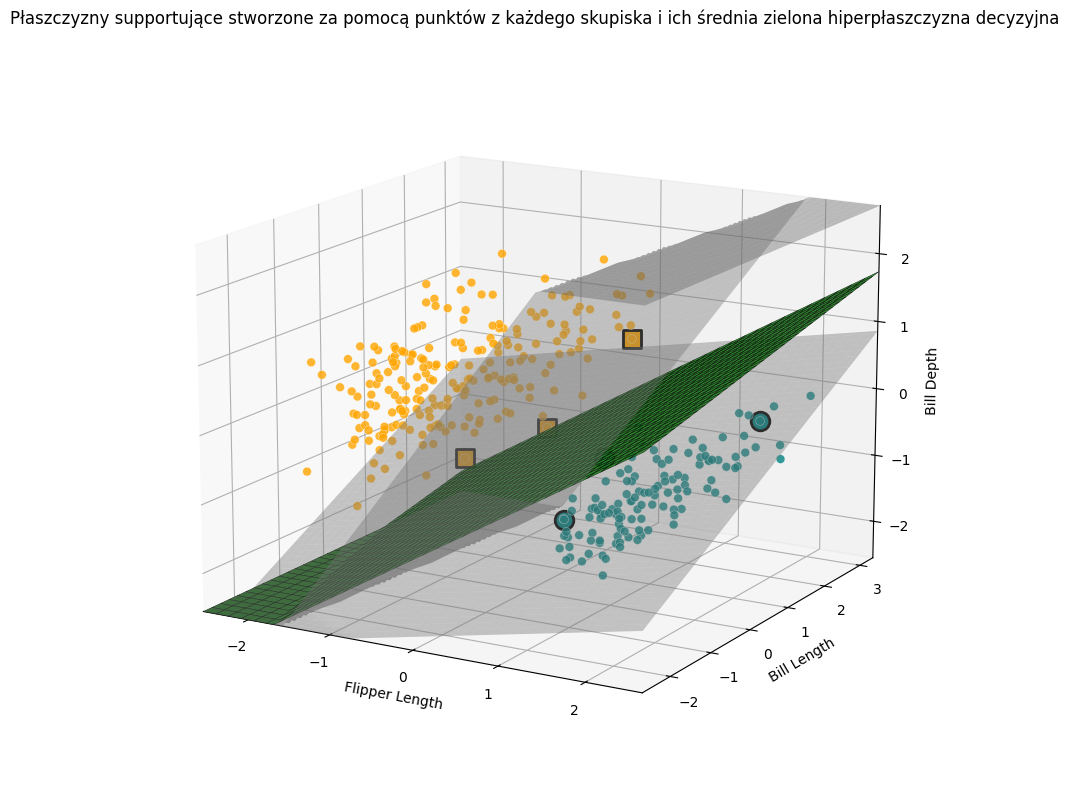

In [21]:
def surface_XYZ(p1, p2, p3):
    v1 = p2 - p1
    v2 = p3 - p1
    n = np.cross(v1, v2) #iloczyn wektorowy, wynikowy wektor jest prostopadły do obu tych wektorów, a więc i do całej płaszczyzny
    a, b, c = n
    d = -np.dot(n, p1)

    x_range = np.linspace(data_SVM['flipper_length_mm'].min()-0.5, data_SVM['flipper_length_mm'].max()+0.5, 100)
    y_range = np.linspace(data_SVM['bill_length_mm'].min()-0.5, data_SVM['bill_length_mm'].max()+0.5, 100)
    X, Y = np.meshgrid(x_range, y_range)

    # Bezpieczne dzielenie przez C
    eps = 1e-10
    if abs(c) < eps:
        c = eps
    
    Z = (-a * X - b * Y - d) / c
    
    z_min, z_max = data_SVM['bill_depth_mm'].min() - 0.5, data_SVM['bill_depth_mm'].max() + 0.5
    Z = np.clip(Z, z_min, z_max)

    return [X, Y, Z]


pg = [s[1].values for s in support_obj]
po = [s[2].values for s in support_obj]
mid = [(pg[i] + po[i]) / 2 for i in range(3)]




colors = {0: 'orange', 1: 'teal'}

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(*surface_XYZ(pg[0], pg[1], pg[2]), alpha=0.4, color='gray', lw=0)
ax.plot_surface(*surface_XYZ(po[0], po[1], po[2]), alpha=0.4, color='gray', lw=0)


ax.plot_surface(*surface_XYZ(mid[0], mid[1], mid[2]), 
                alpha=0.9,
                color='forestgreen', 
                edgecolor='black',
                lw=0.3, 
                rcount=40, ccount=40)

ax.scatter(
    data_SVM['flipper_length_mm'], 
    data_SVM['bill_length_mm'], 
    data_SVM['bill_depth_mm'], 
    c=data_SVM['SVM'].map(colors), 
    s=40,
    alpha=0.8,
    edgecolors='white',
    linewidth=0.3
)

for sup in support_obj:
    g, o = sup[1], sup[2]
    # Gentoo
    ax.scatter(g['flipper_length_mm'], g['bill_length_mm'], g['bill_depth_mm'], c='teal', s=180, marker='o', 
                edgecolors='black', linewidth=2, depthshade=False)
    # Other
    ax.scatter(o['flipper_length_mm'], o['bill_length_mm'], o['bill_depth_mm'], c='orange', s=180, marker='s', 
                edgecolors='black', linewidth=2, depthshade=False)


ax.set_xlim(data_SVM['flipper_length_mm'].min()-0.5, data_SVM['flipper_length_mm'].max()+0.5)
ax.set_ylim(data_SVM['bill_length_mm'].min()-0.5, data_SVM['bill_length_mm'].max()+0.5)
ax.set_zlim(data_SVM['bill_depth_mm'].min()-0.5, data_SVM['bill_depth_mm'].max()+0.5)

ax.view_init(azim=-60, elev=15)

ax.set_xlabel("Flipper Length")
ax.set_ylabel("Bill Length")
ax.set_zlabel("Bill Depth")

plt.title("Płaszczyzny supportujące stworzone za pomocą punktów z każdego skupiska i ich średnia zielona hiperpłaszczyzna decyzyjna")
plt.show()


Szybki test: <br>Aby sprawdzić czy nasza Hiperpłaszczyzna decyzyjna jest prawidłowa możemy podstawić do równania płaszczyzny wszystkie punkty i sprawdzić czy leża po dobrej stronie
1. Równe 0 - punkt nalezy do płaszczyzny
2. Ujemne - punkt jest pod płaszczyną (należy do skupiska Others)
3. Dodatnie - punkt jest nad płaszczyzną (nalezy do skupiska gatunku Gentoo)

In [22]:
p1_mid = mid[0] 
p2_mid = mid[1]
p3_mid = mid[2]

# wektor normalny n i współczynnik D dla płaszczyzny MID
v1 = p2_mid - p1_mid
v2 = p3_mid - p1_mid
n = np.cross(v1, v2) #iloczyn wektorowy, wynikowy wektor jest prostopadły do obu tych wektorów, a więc i do całej płaszczyzny
a, b, c = n
d = -np.dot(n, p1_mid)
    

def check_side_SVM_row(row):
    return a*row['flipper_length_mm'] + b*row['bill_length_mm'] + c*row['bill_depth_mm'] + d

def check_side_SVM_seperate(flipper_length_mm, bill_length_mm, bill_depth_mm):
    return a*flipper_length_mm + b*bill_length_mm + c*bill_depth_mm + d

data_SVM['score'] = data_SVM.apply(check_side_SVM_row, axis=1)


accuracy = ((data_SVM['score'] > 0).astype(int) == data_SVM['SVM']).mean()
if accuracy < 0.5:  #najprawdopodobniej wtedy są na odwrót 
    accuracy = 1 - accuracy

print(f"Celność separacji płaszczyzny: {accuracy*100:.2f}%")
print(f"Liczba punktów po złej stronie płaszczyzny: {int(len(data)*(1-accuracy))}")

Celność separacji płaszczyzny: 99.71%
Liczba punktów po złej stronie płaszczyzny: 1


ETAP 2 - BAYESOWSKI KLASYFIKATOR

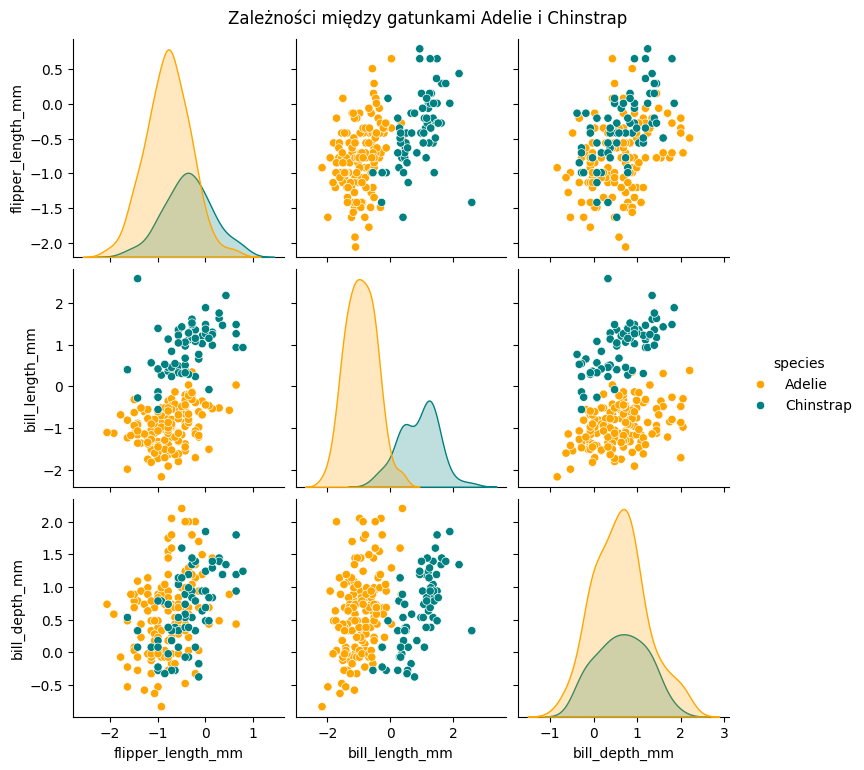

In [23]:
data_bayes = data[["flipper_length_mm", 'bill_length_mm', 'bill_depth_mm', 'species']]
data_bayes = data_bayes[data_bayes["species"] != "Gentoo"]

sns.pairplot(data_bayes, hue='species', palette={"Adelie": 'orange', "Chinstrap": 'teal'}, diag_kind='kde')
plt.suptitle("Zależności między gatunkami Adelie i Chinstrap", y=1.02)
plt.show()




Na pairplot wyżej patrząc na wykresy na przekątnej widać że dane w każdej cesze układają się w rozkład normalny, jedynie bill_length dla gatunku Chinstrap jest podwójnym rozkładem normalnym. <br>
Bill length jest bardzo dobrą cechą do klasyfikacji, ponieważ rozkłady gatunków tylko delikatnie się nakładają, znacznie gorszy jest tutaj flipper length i beznadziejny bill_depth gdzie rozkłady idealnie się nakładają. 

Zdefiniowanie naszego APRIORI jako częstość występowania danego gatunku w naszej populacji treningowej.

In [24]:
APRIORI = {"Adelie": 0,"Chinstrap": 0}
n = len(data_bayes)

print("APRIORI:\n")
for specie in APRIORI.keys():
    prob = len(data_bayes[data_bayes["species"] == specie]) / n
    APRIORI[specie] = prob
    print(f"Gatunek {specie} = {round(prob*100, 2)} %")


APRIORI:

Gatunek Adelie = 69.09 %
Gatunek Chinstrap = 30.91 %


In [25]:
stats = data_bayes.groupby('species').agg(["mean", "std"])

# rozkłady normalne
fetures_distributions = {
    "Adelie": {
                "flipper_length_mm": stats.loc['Adelie', 'flipper_length_mm'], 
                "bill_length_mm": stats.loc['Adelie', 'bill_length_mm'], 
                "bill_depth_mm": stats.loc['Adelie', 'bill_depth_mm']},
    "Chinstrap": {
                "flipper_length_mm": stats.loc['Chinstrap', 'flipper_length_mm'], 
                "bill_length_mm": 0, 
                "bill_depth_mm": stats.loc['Chinstrap', 'bill_depth_mm']}}


# podówjny rozkład normalny dla Chinstrap - bill_length_mm
ch_bill_len = data_bayes[data_bayes["species"] == "Chinstrap"]["bill_length_mm"]

# model dla 2 komponentów
gmm = GaussianMixture(n_components=2)
gmm.fit(ch_bill_len.values.reshape(-1, 1))

fetures_distributions["Chinstrap"]["bill_length_mm"] = gmm


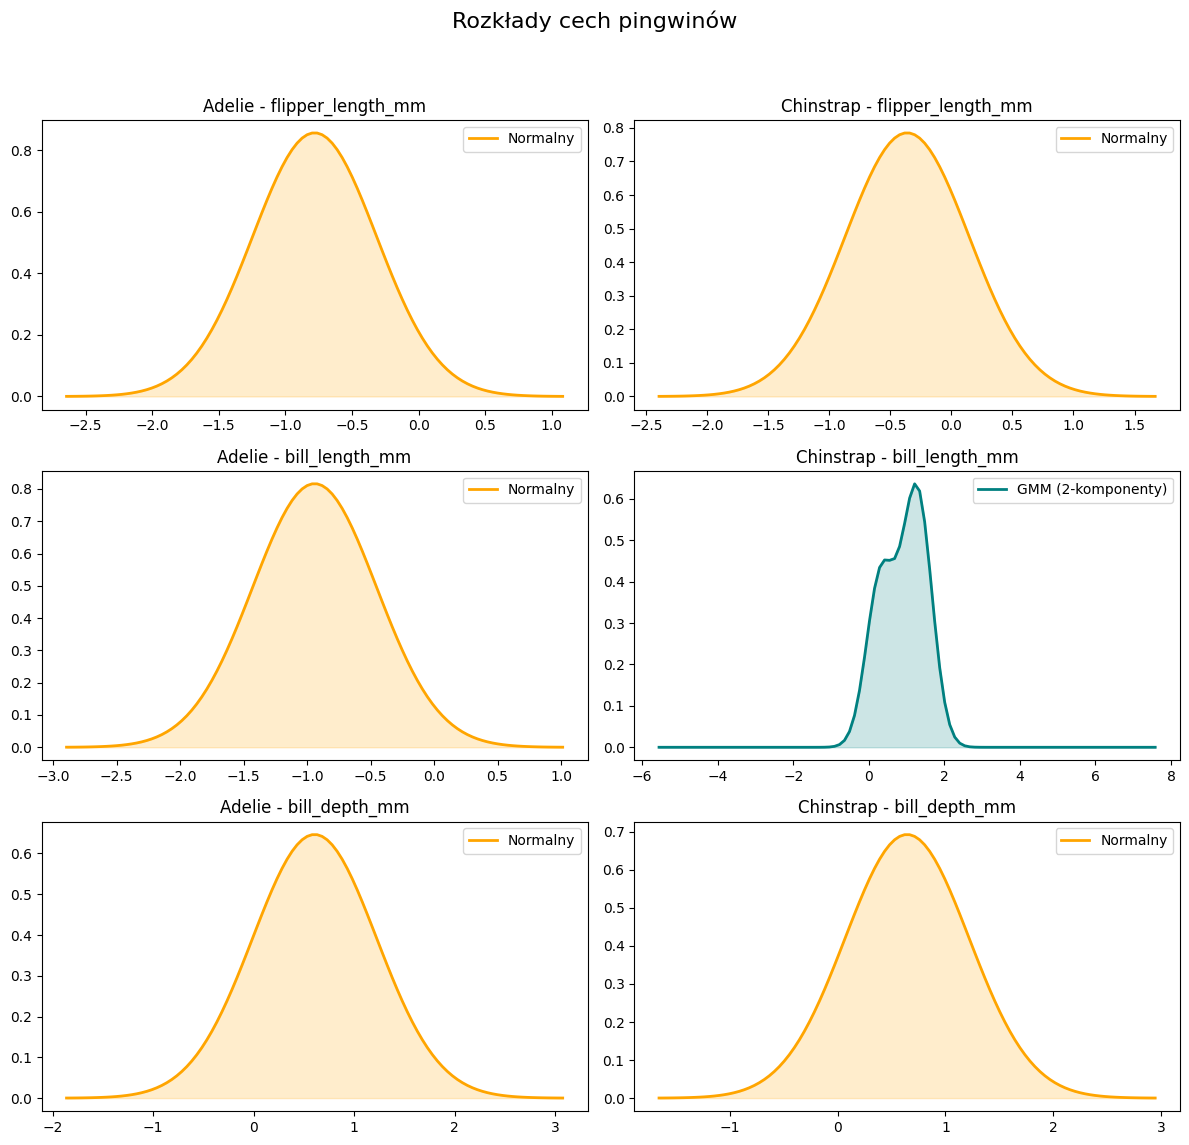

In [26]:
species_list = ["Adelie", "Chinstrap"]
features = ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('Rozkłady cech pingwinów', fontsize=16)

for i, feature in enumerate(features):
    for j, species in enumerate(species_list):
        ax = axes[i, j]
        dist = fetures_distributions[species][feature]
        
        if species == "Chinstrap" and feature == "bill_length_mm":
            # Dane dla GMM (podwójny rozkład)
            x = np.linspace(ch_bill_len.min() - 5, ch_bill_len.max() + 5, 100)
            
            pdf = np.zeros_like(x)
            for m, v, w in zip(dist.means_.flatten(), dist.covariances_.flatten(), dist.weights_):
                pdf += w * norm.pdf(x, m, np.sqrt(v))
            
            ax.plot(x, pdf, color='teal', lw=2, label='GMM (2-komponenty)')
            ax.fill_between(x, pdf, color='teal', alpha=0.2)
        else:
            # Dane dla zwykłych rozkładu normalnego
            mean, std = dist['mean'], dist['std']
            x = np.linspace(mean - 4*std, mean + 4*std, 100)
            pdf = norm.pdf(x, mean, std)
            
            ax.plot(x, pdf, color='orange', lw=2, label='Normalny')
            ax.fill_between(x, pdf, color='orange', alpha=0.2)

        ax.set_title(f"{species} - {feature}")
        ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

TERAZ MOŻNA ZŁOŻYĆ DWA OPRACOWANE KLASYFIKATORY W JEDNĄ FUNCKJĘ DECYZYJNĄ

In [27]:
def Specie_Classification(flipper_length_mm, bill_length_mm, bill_depth_mm):

    scaled_data = scaler.transform([[flipper_length_mm, bill_length_mm, bill_depth_mm]])

    flipper_len_scaled = scaled_data[0][0]
    bill_len_scaled = scaled_data[0][1]
    bill_depth_scaled = scaled_data[0][2]

    if check_side_SVM_seperate(flipper_len_scaled, bill_len_scaled, bill_depth_scaled) > 0:
        return "Gentoo"
    
    
    prob_chinstrap = APRIORI["Chinstrap"]
    prob_chinstrap *= norm.pdf(flipper_len_scaled, 
                                  loc=fetures_distributions["Chinstrap"]["flipper_length_mm"]['mean'], 
                                  scale=fetures_distributions["Chinstrap"]["flipper_length_mm"]['std'])
    prob_chinstrap *= np.exp(gmm.score_samples([[bill_len_scaled]]))[0]
    prob_chinstrap *= norm.pdf(bill_depth_scaled, 
                                  loc=fetures_distributions["Chinstrap"]["bill_depth_mm"]['mean'], 
                                  scale=fetures_distributions["Chinstrap"]["bill_depth_mm"]['std'])
    prob_chinstrap *= 100
    
    prob_adelie = APRIORI["Adelie"]
    prob_adelie *= norm.pdf(flipper_len_scaled, 
                                  loc=fetures_distributions["Adelie"]["flipper_length_mm"]['mean'], 
                                  scale=fetures_distributions["Adelie"]["flipper_length_mm"]['std'])
    prob_adelie *= norm.pdf(bill_len_scaled, 
                                  loc=fetures_distributions["Adelie"]["bill_length_mm"]['mean'], 
                                  scale=fetures_distributions["Adelie"]["bill_length_mm"]['std'])
    prob_adelie *= norm.pdf(bill_depth_scaled, 
                                  loc=fetures_distributions["Adelie"]["bill_depth_mm"]['mean'], 
                                  scale=fetures_distributions["Adelie"]["bill_depth_mm"]['std'])
    prob_adelie *= 100

    prob_adelie_scaled =  prob_adelie / (prob_chinstrap + prob_adelie) * 100
    prob_chinstrap_scaled = prob_chinstrap / (prob_chinstrap + prob_adelie) * 100


    print("Szanse: Adelie:", round(prob_adelie_scaled),"%, Chinstrap:",round(prob_chinstrap_scaled),"%")
    if prob_chinstrap_scaled > prob_adelie_scaled:
        return "Chinstrap"
    return "Adelie"

TESTOWE UŻYCIE DLA KILKU NOWYCH PINGWINÓW

In [28]:
#Gentoo
print("1. Testowy pingwin Gentoo : ")
res = Specie_Classification(221, 48.5, 15)
print("Wynik :", res, end="\n\n")

#Adelie
print("2. Testowy pingwin Adelie ")
res = Specie_Classification(186, 37.5, 18.5)
print("Wynik :", res, end="\n\n")

#Chinstrap
print("3. Testowy pingwin Chinstrap : ")
res = Specie_Classification(197.5, 50.5, 17.5)
print("Wynik :", res, end="\n\n")

#Adelie/Chinstrap
print("4. Testowy pingwin Adelie/Chinstrap : ")
res = Specie_Classification(193.0, 44.5, 17.0)
print("Wynik :", res, end="\n\n")

1. Testowy pingwin Gentoo : 
Wynik : Gentoo

2. Testowy pingwin Adelie 
Szanse: Adelie: 100 %, Chinstrap: 0 %
Wynik : Adelie

3. Testowy pingwin Chinstrap : 
Szanse: Adelie: 0 %, Chinstrap: 100 %
Wynik : Chinstrap

4. Testowy pingwin Adelie/Chinstrap : 
Szanse: Adelie: 37 %, Chinstrap: 63 %
Wynik : Chinstrap



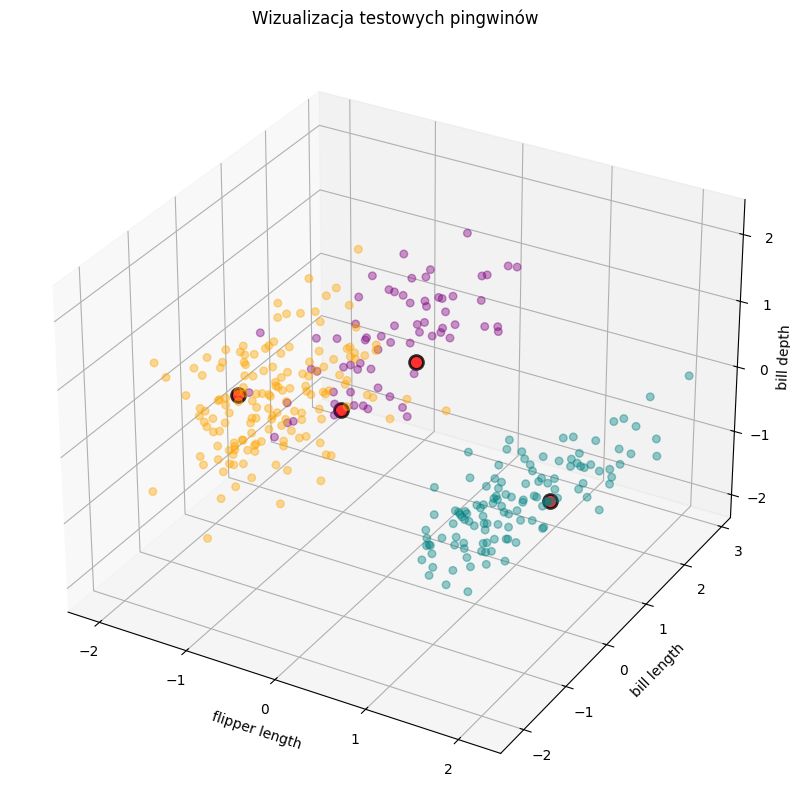

In [29]:
colors = {'Adelie': 'orange', 'Chinstrap': 'purple', 'Gentoo': 'teal'}

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data['flipper_length_mm'], 
    data['bill_length_mm'], 
    data['bill_depth_mm'], 
    c=data['species'].map(colors), 
    s=30,
    alpha=0.4
)
for test_obj in scaler.transform([[221, 48.5, 15], [186, 37.5, 18.5], [197.5, 50.5, 17.5], [193.0, 44.5, 17.0]]):
    gentoo_obj = sup[1]
    ax.scatter(test_obj[0], test_obj[1], test_obj[2], c='red', s=100, marker='o', edgecolors='black',linewidths=2, alpha=0.8)

ax.set_xlabel("flipper length")
ax.set_ylabel("bill length")
ax.set_zlabel("bill depth", labelpad=0)

plt.title("Wizualizacja testowych pingwinów")
plt.show()